In [1]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import shap

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [64]:
feature_names = [
    r'$\sigma_{sp}$_B',   # 对应 BS_B
    r'$\sigma_{sp}$_G',   # 对应 BS_G
    r'$\sigma_{sp}$_R',   # 对应 BS_R
    'AE_BG',              # 这里暂未做替换
    'AE_BR',
    'AE_GR',
    r'$\sigma_{bsp}$_B',  # 对应 BBS_B
    r'$\sigma_{bsp}$_G',  # 对应 BBS_G
    r'$\sigma_{bsp}$_R',  # 对应 BBS_R
    'BSF_B',             # 未要求改名则可保留
    'BSF_G',
    'BSF_R',
    'SSA_B',
    'SSA_G',
    'SSA_R',
    r'$\sigma_{ap}$_B',   # 对应 BA_B
    r'$\sigma_{ap}$_G',   # 对应 BA_G
    r'$\sigma_{ap}$_R',   # 对应 BA_R
]

In [165]:
shap_values_guc = np.load(r'E:/aabc/myDeepTree/data-250415/ba_qc/guc/gucshap_values.npy')
# shap_interaction_values_guc = np.load('E:/aabc/myDeepTree/data-250329/guc/gucshap_interaction_values.npy')
shap_values_sgp = np.load('E:/aabc/myDeepTree/data-250415/ba_qc/sgp/sgpshap_values.npy')
# shap_interaction_values_sgp = np.load('E:/aabc/myDeepTree/data-250327/sgpshap_interaction_values.npy')
shap_values_asi = np.load('E:/aabc/myDeepTree/data-250415/ba_qc/asi/asishap_values.npy')
# shap_interaction_values_asi = np.load('E:/aabc/myDeepTree/data-250329/asishap_interaction_values.npy')
shap_values_ena = np.load('E:/aabc/myDeepTree/data-250415/ba_qc/ena/enashap_values.npy')
# shap_interaction_values_ena = np.load('E:/aabc/myDeepTree/data-250329/enashap_interaction_values.npy')
shap_values_mos = np.load('E:/aabc/myDeepTree/data-250415/ba_qc/mos/mosshap_values.npy')
# shap_interaction_values_mos = np.load('E:/aabc/myDeepTree/data-250329/mosh/moshshap_interaction_values.npy')
shap_values_mos.shape

(3000, 18)

In [ ]:
columns_to_keep = [
     "Bs_B", "Bs_G", "Bs_R", "AE_BG", "AE_BR", "AE_GR",
    "Bbs_B", "Bbs_G", "Bbs_R", "bsf_B", "bsf_G", "bsf_R",
    "ssa_B", "ssa_G", "ssa_R", "RH_Neph_Dry",
    "Ba_B_Weiss", "Ba_G_Weiss", "Ba_R_Weiss",'CCN'
]
data_sgp = pd.read_csv(r'E:/aabc\myDeepTree\data-250329/sgp.csv', usecols=columns_to_keep)

data_sgp

,N_CCN,Bs_B,Bs_G,Bs_R,AE_BG,AE_BR,AE_GR,Bbs_B,Bbs_G,Bbs_R,bsf_B,bsf_G,bsf_R,ssa_B,ssa_G,ssa_R,Ba_B_combined,Ba_G_combined,Ba_R_combined
0,994.422311,36.315190,27.969503,18.052286,1.991714,2.103956,2.197353,3.773548,3.464851,2.792726,0.103911,0.123880,0.154702,0.945319,0.940363,0.927178,2.100619,1.773787,1.417845
1,989.845493,34.604317,26.661331,17.208166,1.988988,2.103031,2.197925,4.021618,3.626426,2.454104,0.116217,0.136018,0.142613,0.945298,0.940014,0.925638,2.002482,1.701350,1.382432
2,912.411032,33.845818,25.782219,16.443419,2.075684,2.170882,2.250096,4.046744,3.500269,2.754570,0.119564,0.135763,0.167518,0.944765,0.939673,0.923352,1.978768,1.655214,1.364971
3,878.517933,33.509308,25.435738,16.426088,2.102668,2.138113,2.167607,3.899488,3.452181,2.591593,0.116370,0.135722,0.157773,0.942546,0.937432,0.923040,2.042605,1.697675,1.369560
4,844.085035,32.986706,24.905092,15.399483,2.143586,2.296041,2.422899,3.651942,2.967232,2.461858,0.110710,0.119142,0.159866,0.934295,0.928041,0.907154,2.319807,1.931104,1.576125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
519370,1208.105222,16.518955,13.191820,8.967399,1.715521,1.841741,1.946768,2.097123,2.088540,1.851044,0.126953,0.158321,0.206419,0.867610,0.869039,0.850901,2.520662,1.987958,1.571312
519371,1223.546427,16.527730,12.643555,8.999412,2.043357,1.794988,1.588321,2.775113,2.213680,1.122937,0.167906,0.175084,0.124779,0.870512,0.865075,0.863907,2.458479,1.971996,1.417696
519372,1208.973615,17.065367,13.013078,8.050191,2.067798,2.269847,2.437971,2.870734,2.225497,1.571510,0.168220,0.171020,0.195214,0.875343,0.869308,0.836116,2.430267,1.956392,1.577886
519373,1186.972453,16.179010,12.165983,6.991109,2.174389,2.549926,2.862409,2.203812,1.868653,1.517139,0.136214,0.153597,0.217010,0.874024,0.867684,0.827721,2.331940,1.855233,1.455110


In [60]:
# data reading
data_sgp = pd.read_csv(r'E:\aabc\myDeepTree\data-250415/ba_qc/sgp.csv')
data_sgp = data_sgp.replace(-9999, float('nan'))
data_sgp.iloc[:, 0] = pd.to_numeric(data_sgp.iloc[:, 0], errors='coerce')
data_sgp = data_sgp.dropna()
data_sgp.columns = [
    'CCN', 'BS_B', 'BS_G', 'BS_R', 'AE_BG', 'AE_BR', 'AE_GR', 'BBS_B', 'BBS_G', 'BBS_R',
    'BSF_B', 'BSF_G', 'BSF_R',  'SSA_B', 'SSA_G', 'SSA_R', 
    'BA_B', 'BA_G', 'BA_R'
]
data_sgp

,CCN,BS_B,BS_G,BS_R,AE_BG,AE_BR,AE_GR,BBS_B,BBS_G,BBS_R,BSF_B,BSF_G,BSF_R,SSA_B,SSA_G,SSA_R,BA_B,BA_G,BA_R
0,994.422311,36.315190,27.969503,18.052286,1.991714,2.103956,2.197353,3.773548,3.464851,2.792726,0.103911,0.123880,0.154702,0.945319,0.940363,0.927178,2.100619,1.773787,1.417845
1,989.845493,34.604317,26.661331,17.208166,1.988988,2.103031,2.197925,4.021618,3.626426,2.454104,0.116217,0.136018,0.142613,0.945298,0.940014,0.925638,2.002482,1.701350,1.382432
2,912.411032,33.845818,25.782219,16.443419,2.075684,2.170882,2.250096,4.046744,3.500269,2.754570,0.119564,0.135763,0.167518,0.944765,0.939673,0.923352,1.978768,1.655214,1.364971
3,878.517933,33.509308,25.435738,16.426088,2.102668,2.138113,2.167607,3.899488,3.452181,2.591593,0.116370,0.135722,0.157773,0.942546,0.937432,0.923040,2.042605,1.697675,1.369560
4,844.085035,32.986706,24.905092,15.399483,2.143586,2.296041,2.422899,3.651942,2.967232,2.461858,0.110710,0.119142,0.159866,0.934295,0.928041,0.907154,2.319807,1.931104,1.576125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
519370,1208.105222,16.518955,13.191820,8.967399,1.715521,1.841741,1.946768,2.097123,2.088540,1.851044,0.126953,0.158321,0.206419,0.867610,0.869039,0.850901,2.520662,1.987958,1.571312
519371,1223.546427,16.527730,12.643555,8.999412,2.043357,1.794988,1.588321,2.775113,2.213680,1.122937,0.167906,0.175084,0.124779,0.870512,0.865075,0.863907,2.458479,1.971996,1.417696
519372,1208.973615,17.065367,13.013078,8.050191,2.067798,2.269847,2.437971,2.870734,2.225497,1.571510,0.168220,0.171020,0.195214,0.875343,0.869308,0.836116,2.430267,1.956392,1.577886
519373,1186.972453,16.179010,12.165983,6.991109,2.174389,2.549926,2.862409,2.203812,1.868653,1.517139,0.136214,0.153597,0.217010,0.874024,0.867684,0.827721,2.331940,1.855233,1.455110


In [10]:
import pandas as pd

# 假设 df 是包含你数据的 data_sgpFrame
# 首先查看 h 字段的当前数据类型
print(data_sgp['h'].dtype)

# 如果 h 字段是 object 类型，尝试将其转换为 float
# 这里假设 h 字段应该包含数值数据
data_sgp['h'] = pd.to_numeric(data_sgp['h'], errors='coerce')

# 再次查看转换后的数据类型
print(data_sgp['h'].dtype)

# 检查是否有转换失败的情况，这些会被转换为 NaN
if data_sgp['h'].isnull().any():
    print("Some values in 'h' could not be converted and are set as NaN.")

# 处理 NaN 值，例如填充或删除
# 下面的代码示例将所有 NaN 值填充为0
data_sgp['h'] = data_sgp['h'].fillna(0)
data_sgp

object
float64


,h,BS_B,BS_G,BS_R,AE_BG,AE_BR,AE_GR,BBS_B,BBS_G,BBS_R,BSF_B,BSF_G,BSF_R,SSA_B,SSA_G,SSA_R,RH,BA_B,BA_G,BA_R
0,0.415017,36.315190,27.969503,18.052286,1.991714,2.103956,2.197353,3.773548,3.464851,2.792726,0.103911,0.123880,0.154702,0.945319,0.940363,0.927178,52.383335,2.683741,2.244908,1.734303
1,0.326982,33.598194,25.436905,16.117731,2.122524,2.207794,2.278747,3.455863,3.155629,2.477978,0.102859,0.124057,0.153742,0.931388,0.924001,0.904566,51.091667,3.012022,2.518159,1.981802
2,0.382092,34.949837,26.573984,17.183304,2.089801,2.129643,2.162797,4.257614,3.630653,3.158910,0.121821,0.136624,0.183836,0.928930,0.921229,0.903211,51.866670,3.230149,2.714371,2.139569
3,0.609715,64.140060,49.487087,32.391220,1.978259,2.052926,2.115057,6.822793,5.727760,4.780735,0.106373,0.115743,0.147594,0.967287,0.963531,0.953097,59.450000,3.331122,2.790050,2.209870
4,0.500235,60.450535,46.284523,29.718681,2.036688,2.135829,2.218324,6.579695,5.295833,3.997323,0.108844,0.114419,0.134505,0.964001,0.959304,0.947140,59.858334,3.361542,2.830106,2.231266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101526,0.259454,5.321991,4.339066,2.853034,1.557456,1.901198,2.187225,1.202994,0.884534,0.462983,0.226042,0.203853,0.162277,0.945481,0.950415,0.937789,28.766666,0.395022,0.302643,0.242212
101527,0.216180,5.483855,3.968478,2.359517,2.466944,2.531445,2.585116,1.277014,0.942134,0.741173,0.232868,0.237404,0.314121,0.947565,0.935969,0.935215,28.841665,0.404042,0.345446,0.208192
101528,0.223390,4.481437,3.426469,3.135542,2.047332,0.959898,0.055044,0.857065,0.671301,0.555872,0.191248,0.195916,0.177281,0.946798,0.951877,0.971162,28.116667,0.329835,0.233296,0.147777
101529,0.257105,4.337648,3.245553,2.213018,2.212341,1.992776,1.810077,1.020489,0.552924,0.458888,0.235263,0.170364,0.207358,0.945636,0.950967,0.944806,28.200000,0.328948,0.225958,0.169691


In [61]:
data_sgp = data_sgp[data_sgp['CCN'] >0]
# data_sgp = data_sgp[data_sgp['h'] <1]
data_sgp = data_sgp[data_sgp['AE_BG'] >0]
data_sgp = data_sgp[data_sgp['AE_BR'] >0]
data_sgp = data_sgp[data_sgp['AE_GR'] >0]
data_sgp = data_sgp[data_sgp['BA_B'] >0]
data_sgp = data_sgp[data_sgp['BA_G'] >0]
data_sgp = data_sgp[data_sgp['BA_R'] >0]
data_sgp = data_sgp[data_sgp['BS_B'] >0]
data_sgp = data_sgp[data_sgp['BS_G'] >0]
data_sgp = data_sgp[data_sgp['BS_R'] >0]
data_sgp = data_sgp[data_sgp['BBS_B'] >0]
data_sgp = data_sgp[data_sgp['BBS_G'] >0]
data_sgp = data_sgp[data_sgp['BBS_R'] >0]
data_sgp = data_sgp[data_sgp['BSF_B'] >0]
data_sgp = data_sgp[data_sgp['BSF_G'] >0]   
data_sgp = data_sgp[data_sgp['BSF_R'] >0]
data_sgp = data_sgp[data_sgp['SSA_B'] <1]
data_sgp = data_sgp[data_sgp['SSA_G'] <1]
data_sgp = data_sgp[data_sgp['SSA_R'] <1]
data_sgp = data_sgp[data_sgp['SSA_B'] >0]
data_sgp = data_sgp[data_sgp['SSA_G'] >0]
data_sgp = data_sgp[data_sgp['SSA_R'] >0]
def remove_outliers(df):
    # Remove outliers using the 3-sigma rule
    for column in df.columns:
        mean = df[column].mean()
        std = df[column].std()
        cutoff = std * 3
        lower = mean - cutoff
        upper = mean + cutoff
        df = df[(df[column] > lower) & (df[column] < upper)]
    return df

# Apply function to remove outliers
data_sgp = remove_outliers(data_sgp)
data_sgp


,CCN,BS_B,BS_G,BS_R,AE_BG,AE_BR,AE_GR,BBS_B,BBS_G,BBS_R,BSF_B,BSF_G,BSF_R,SSA_B,SSA_G,SSA_R,BA_B,BA_G,BA_R
0,994.422311,36.315190,27.969503,18.052286,1.991714,2.103956,2.197353,3.773548,3.464851,2.792726,0.103911,0.123880,0.154702,0.945319,0.940363,0.927178,2.100619,1.773787,1.417845
1,989.845493,34.604317,26.661331,17.208166,1.988988,2.103031,2.197925,4.021618,3.626426,2.454104,0.116217,0.136018,0.142613,0.945298,0.940014,0.925638,2.002482,1.701350,1.382432
2,912.411032,33.845818,25.782219,16.443419,2.075684,2.170882,2.250096,4.046744,3.500269,2.754570,0.119564,0.135763,0.167518,0.944765,0.939673,0.923352,1.978768,1.655214,1.364971
3,878.517933,33.509308,25.435738,16.426088,2.102668,2.138113,2.167607,3.899488,3.452181,2.591593,0.116370,0.135722,0.157773,0.942546,0.937432,0.923040,2.042605,1.697675,1.369560
4,844.085035,32.986706,24.905092,15.399483,2.143586,2.296041,2.422899,3.651942,2.967232,2.461858,0.110710,0.119142,0.159866,0.934295,0.928041,0.907154,2.319807,1.931104,1.576125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
519370,1208.105222,16.518955,13.191820,8.967399,1.715521,1.841741,1.946768,2.097123,2.088540,1.851044,0.126953,0.158321,0.206419,0.867610,0.869039,0.850901,2.520662,1.987958,1.571312
519371,1223.546427,16.527730,12.643555,8.999412,2.043357,1.794988,1.588321,2.775113,2.213680,1.122937,0.167906,0.175084,0.124779,0.870512,0.865075,0.863907,2.458479,1.971996,1.417696
519372,1208.973615,17.065367,13.013078,8.050191,2.067798,2.269847,2.437971,2.870734,2.225497,1.571510,0.168220,0.171020,0.195214,0.875343,0.869308,0.836116,2.430267,1.956392,1.577886
519373,1186.972453,16.179010,12.165983,6.991109,2.174389,2.549926,2.862409,2.203812,1.868653,1.517139,0.136214,0.153597,0.217010,0.874024,0.867684,0.827721,2.331940,1.855233,1.455110


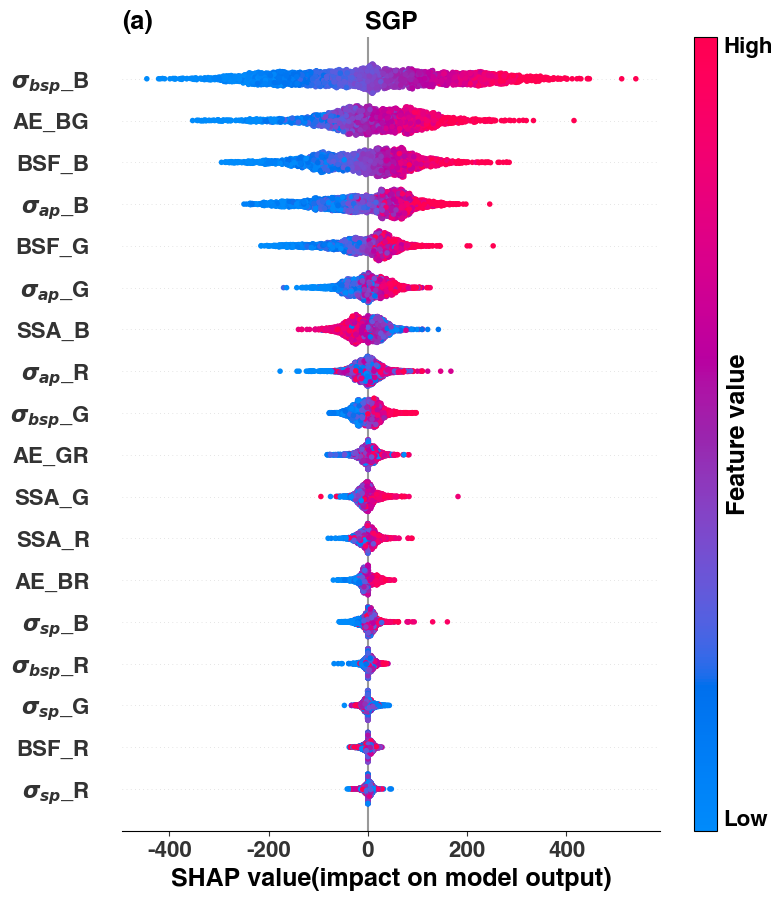

In [66]:


X_sgp = data_sgp.drop('CCN', axis=1)  # Features
y_sgp = data_sgp['CCN']  # Features
X_train_sgp, X_test_sgp, y_train_sgp, y_test_sgp = train_test_split(X_sgp, y_sgp, test_size=0.2, random_state=2024)
# Randomly select 3000 samples for SHAP analysis
np.random.seed(2024)
indices = np.random.choice(X_test_sgp.shape[0], 3000, replace=False)
# selected_X_test = X_test  # Comment this out if using the random subset
selected_X_test = X_test_sgp.iloc[indices]
# summary
import os
plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams['font.weight'] = 'bold'

shap.summary_plot(shap_values_sgp, selected_X_test,feature_names=feature_names, show=False,color_bar=False)
cbar = plt.colorbar(aspect=35)
cbar.set_label('Feature value',size=18,fontname='Helvetica', fontweight='bold')
cbar.ax.set_yticklabels([])
cbar.ax.tick_params(axis='y', which='both', length=0)
cbar.ax.text(1.3,0,'Low',va='bottom',ha='left',transform=cbar.ax.transAxes,fontsize=16)
cbar.ax.text(1.3,1,'High',va='top',ha='left',transform=cbar.ax.transAxes,fontsize=16)

plt.xlabel('SHAP value(impact on model output)',fontsize=18,fontname='Helvetica', fontweight='bold')
plt.tick_params(axis='x',labelsize=16)
plt.tick_params(axis='y',labelsize=16)
plt.title('(a)', loc='left', fontsize=18, fontname='Helvetica', fontweight='bold')
plt.title('SGP', fontsize=18, fontname='Helvetica', fontweight='bold')
plt.savefig('E:/aabc/summary/fig-250416/shap-sgp.png',dpi=300,bbox_inches='tight',pad_inches=0)
plt.show()


In [63]:
# save
shap_values_df = pd.DataFrame(shap_values_sgp, columns=X_train_sgp.columns)

shap_values_df.to_csv('E:/aabc\myDeepTree\data-250415/ba_qc/sgp/sgpshap_values.csv', index=False)

feature_importance = np.abs(shap_values_df).mean().sort_values(ascending=False)
feature_importance.to_csv('E:/aabc\myDeepTree\data-250415/ba_qc/sgp/sgpfeature_importance.csv')
total_shap = feature_importance.sum()

# contribution_ratio
feature_contribution_ratio = (feature_importance / total_shap) * 100

feature_contribution_ratio.to_csv('E:/aabc\myDeepTree\data-250415/ba_qc/sgp/sgpfeature_contribution_ratio.csv')
feature_contribution_ratio

BBS_B    23.323345
AE_BG    13.197706
BSF_B    12.439458
BA_B     11.451874
BSF_G     7.717411
BA_G      5.199674
SSA_B     4.659294
BA_R      3.580731
BBS_G     3.311482
AE_GR     2.295676
SSA_G     2.206314
SSA_R     2.139047
AE_BR     1.978595
BS_B      1.877659
BBS_R     1.299631
BS_G      1.181188
BSF_R     1.169959
BS_R      0.970956
dtype: float64

In [33]:

data_guc = pd.read_csv('E:/aabc\myDeepTree\data-250415/ba_qc/guc.csv')
data_guc = data_guc.replace(-9999, float('nan'))
data_guc.iloc[:, 0] = pd.to_numeric(data_guc.iloc[:, 0], errors='coerce')
data_guc = data_guc.dropna()
data_guc.columns = [
    'CCN', 'BS_B', 'BS_G', 'BS_R', 'AE_BG', 'AE_BR', 'AE_GR', 'BBS_B', 'BBS_G', 'BBS_R',
    'BSF_B', 'BSF_G', 'BSF_R',  'SSA_B', 'SSA_G', 'SSA_R', 
     'BA_B', 'BA_G', 'BA_R'
]
data_guc

,CCN,BS_B,BS_G,BS_R,AE_BG,AE_BR,AE_GR,BBS_B,BBS_G,BBS_R,BSF_B,BSF_G,BSF_R,SSA_B,SSA_G,SSA_R,BA_B,BA_G,BA_R
0,535.120269,74.816250,56.877384,35.668404,2.090991,2.232016,2.349363,8.090380,6.721694,5.473801,0.108137,0.118179,0.153464,1.000252,1.000739,1.001551,-0.018846,-0.041993,-0.055244
1,545.864160,74.636530,57.276478,36.938404,2.019316,2.115565,2.195654,7.799878,6.430795,5.654231,0.104505,0.112276,0.153072,0.994050,0.992684,0.990996,0.446771,0.422109,0.335626
2,550.390953,74.701700,57.454643,36.812330,2.002280,2.131755,2.239491,7.313703,6.425041,5.584107,0.097905,0.111828,0.151691,0.986748,0.984402,0.980871,1.003262,0.910381,0.717933
3,542.025576,75.410805,57.344070,35.277245,2.089040,2.295290,2.466911,7.785453,6.828731,5.431006,0.103241,0.119083,0.153952,0.987453,0.986322,0.979924,0.958205,0.795238,0.722752
4,548.330045,73.943070,56.570800,36.157500,2.042675,2.153007,2.244813,7.625298,6.486101,5.421332,0.103124,0.114655,0.149937,0.993985,0.992129,0.986998,0.447462,0.448811,0.476301
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26772,210.415140,4.221589,3.198411,2.205655,2.117080,1.924244,1.763786,0.946355,0.548142,0.329840,0.224170,0.171379,0.149543,0.807756,0.827585,0.807470,1.004725,0.666340,0.525908
26773,207.452149,4.665992,3.618177,2.337301,1.939912,2.084249,2.204352,1.036953,0.813147,0.665344,0.222236,0.224739,0.284664,0.700383,0.712260,0.675176,1.996062,1.461681,1.124467
26774,202.969963,3.947562,2.921042,1.621305,2.297093,2.705275,3.044923,0.846159,0.663434,0.566705,0.214350,0.227122,0.349537,0.712052,0.677851,0.593225,1.596364,1.388229,1.111729
26775,194.770631,4.104181,3.255551,2.673767,1.766879,1.228852,0.781160,1.405584,0.913345,0.793751,0.342476,0.280550,0.296866,0.758614,0.738702,0.745840,1.305921,1.151571,0.911142


In [34]:

data_guc = data_guc[data_guc['CCN'] >0]
# data_guc = data_guc[data_guc['h'] <1]
data_guc = data_guc[data_guc['AE_BG'] >0]
data_guc = data_guc[data_guc['AE_BR'] >0]
data_guc = data_guc[data_guc['AE_GR'] >0]
data_guc = data_guc[data_guc['BA_B'] >0]
data_guc = data_guc[data_guc['BA_G'] >0]
data_guc = data_guc[data_guc['BA_R'] >0]
data_guc = data_guc[data_guc['BS_B'] >0]
data_guc = data_guc[data_guc['BS_G'] >0]
data_guc = data_guc[data_guc['BS_R'] >0]
data_guc = data_guc[data_guc['BBS_B'] >0]
data_guc = data_guc[data_guc['BBS_G'] >0]
data_guc = data_guc[data_guc['BBS_R'] >0]
data_guc = data_guc[data_guc['BSF_B'] >0]
data_guc = data_guc[data_guc['BSF_G'] >0]   
data_guc = data_guc[data_guc['BSF_R'] >0]
data_guc = data_guc[data_guc['SSA_B'] <1]
data_guc = data_guc[data_guc['SSA_G'] <1]
data_guc = data_guc[data_guc['SSA_R'] <1]
data_guc = data_guc[data_guc['SSA_B'] >0]
data_guc = data_guc[data_guc['SSA_G'] >0]
data_guc = data_guc[data_guc['SSA_R'] >0]
def remove_outliers(df):
    # Remove outliers using the 3-sigma rule
    for column in df.columns:
        mean = df[column].mean()
        std = df[column].std()
        cutoff = std * 3
        lower = mean - cutoff
        upper = mean + cutoff
        df = df[(df[column] > lower) & (df[column] < upper)]
    return df

# Apply function to remove outliers
data_guc = remove_outliers(data_guc)


# Prepare features and target variable
X_guc = data_guc.drop('CCN', axis=1)  # Features
y_guc = data_guc['CCN']  # Features
X_train_guc, X_test_guc, y_train_guc, y_test_guc = train_test_split(X_guc, y_guc, test_size=0.2, random_state=2024)
X_test_guc

,BS_B,BS_G,BS_R,AE_BG,AE_BR,AE_GR,BBS_B,BBS_G,BBS_R,BSF_B,BSF_G,BSF_R,SSA_B,SSA_G,SSA_R,BA_B,BA_G,BA_R
23757,6.403180,5.291791,3.538334,1.454098,1.811808,2.109459,1.325075,0.930362,0.721154,0.206940,0.175812,0.203812,0.914179,0.906742,0.886449,0.601116,0.544257,0.453250
7963,20.278496,15.731019,10.066920,1.936835,2.114561,2.262446,2.949493,2.327634,2.024784,0.145449,0.147965,0.201132,0.923909,0.921815,0.904436,1.670102,1.334253,1.063682
13958,10.969327,8.494010,4.801660,1.950680,2.531886,3.015506,1.835894,1.421792,0.946821,0.167366,0.167388,0.197186,0.951295,0.942768,0.912256,0.561611,0.515642,0.461839
6190,20.465302,16.405731,12.505730,1.686449,1.450972,1.255033,2.295447,2.201525,1.874532,0.112163,0.134192,0.149894,0.946546,0.945606,0.946569,1.155736,0.943698,0.705916
11812,64.967620,50.958225,33.299294,1.852600,2.017616,2.154927,6.931152,5.792567,4.587883,0.106686,0.113673,0.137777,0.960918,0.960461,0.952305,2.642351,2.097786,1.667746
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,29.719393,22.712618,14.640132,2.050887,2.127530,2.191304,3.025582,2.705161,2.268712,0.101805,0.119104,0.154965,0.943681,0.934415,0.911210,1.773657,1.594154,1.426566
11012,22.311884,17.779392,11.666864,1.732055,1.964567,2.158039,2.813090,2.018788,1.564753,0.126080,0.113547,0.134119,0.945697,0.940861,0.929626,1.281172,1.117554,0.883204
26079,7.259691,5.819637,4.305716,1.686443,1.550336,1.437081,1.009513,0.825785,0.440470,0.139057,0.141896,0.102299,0.943401,0.936883,0.940936,0.435543,0.392061,0.270275
18458,30.802341,23.873041,15.378718,1.943807,2.094808,2.220455,3.644241,2.821662,2.441340,0.118311,0.118194,0.158748,0.969196,0.965776,0.951078,0.979000,0.845975,0.791051


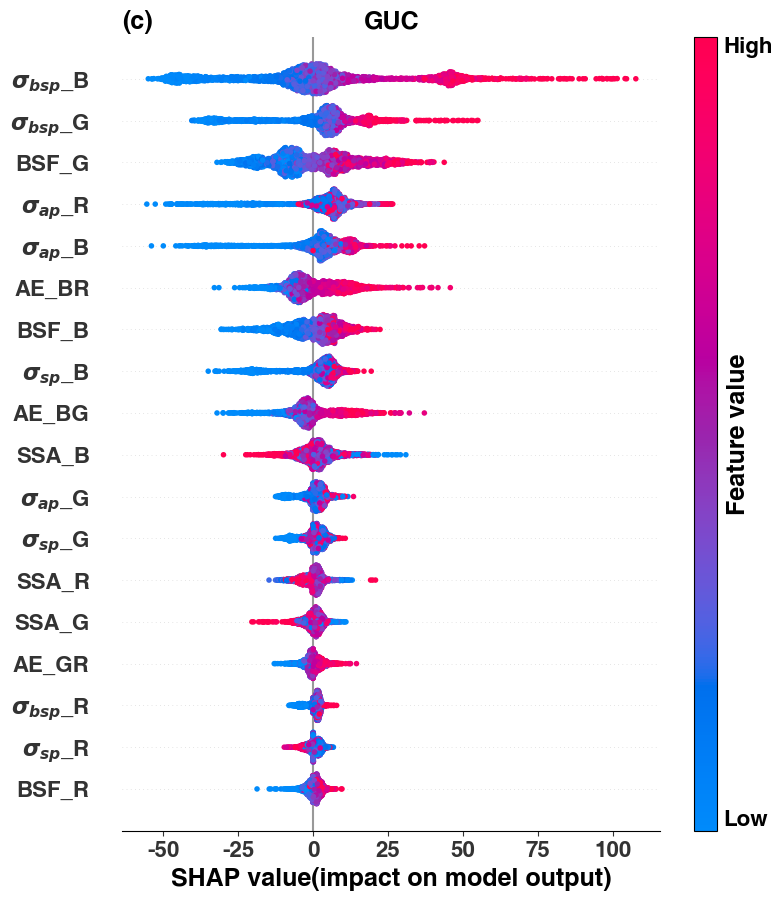

In [67]:

# Randomly select 3000 samples for SHAP analysis
np.random.seed(2024)
indices = np.random.choice(X_test_guc.shape[0], 3000, replace=False)
# selected_X_test = X_test  # Comment this out if using the random subset
selected_X_test = X_test_guc.iloc[indices]
# summary
import os
plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams['font.weight'] = 'bold'
feature_names = [
    r'$\sigma_{sp}$_B',   # 对应 BS_B
    r'$\sigma_{sp}$_G',   # 对应 BS_G
    r'$\sigma_{sp}$_R',   # 对应 BS_R
    'AE_BG',              # 这里暂未做替换
    'AE_BR',
    'AE_GR',
    r'$\sigma_{bsp}$_B',  # 对应 BBS_B
    r'$\sigma_{bsp}$_G',  # 对应 BBS_G
    r'$\sigma_{bsp}$_R',  # 对应 BBS_R
    'BSF_B',             # 未要求改名则可保留
    'BSF_G',
    'BSF_R',
    'SSA_B',
    'SSA_G',
    'SSA_R',
    r'$\sigma_{ap}$_B',   # 对应 BA_B
    r'$\sigma_{ap}$_G',   # 对应 BA_G
    r'$\sigma_{ap}$_R',   # 对应 BA_R
]

# 调用 summary_plot 时加上 feature_names 参数
shap.summary_plot(
    shap_values_guc,
    selected_X_test,
    feature_names=feature_names,
    show=False,
    color_bar=False
)
# shap.summary_plot(shap_values_guc, selected_X_test, show=False,color_bar=False)
cbar = plt.colorbar(aspect=35)
cbar.set_label('Feature value',size=18,fontname='Helvetica', fontweight='bold')
cbar.ax.set_yticklabels([])
cbar.ax.tick_params(axis='y', which='both', length=0)
cbar.ax.text(1.3,0,'Low',va='bottom',ha='left',transform=cbar.ax.transAxes,fontsize=16)
cbar.ax.text(1.3,1,'High',va='top',ha='left',transform=cbar.ax.transAxes,fontsize=16)

plt.xlabel('SHAP value(impact on model output)',fontsize=18,fontname='Helvetica', fontweight='bold')
plt.tick_params(axis='x',labelsize=16)
plt.tick_params(axis='y',labelsize=16)
plt.title('(c)', loc='left', fontsize=18, fontname='Helvetica', fontweight='bold')
plt.title('GUC', fontsize=18, fontname='Helvetica', fontweight='bold')
plt.savefig('E:/aabc/summary/fig-250416/shap-guc.png',dpi=300,bbox_inches='tight',pad_inches=0)
plt.show()


In [36]:
# save
shap_values_df_guc = pd.DataFrame(shap_values_guc, columns=X_train_guc.columns)

shap_values_df_guc
shap_values_df_guc.to_csv('E:/aabc\myDeepTree\data-250415/ba_qc/guc/gucshap_values.csv', index=False)

feature_importance_guc = np.abs(shap_values_df_guc).mean().sort_values(ascending=False)
feature_importance_guc.to_csv('E:/aabc\myDeepTree\data-250415/ba_qc/guc/gucfeature_importance.csv')
total_shap_guc = feature_importance_guc.sum()

# contribution_ratio
feature_contribution_ratio_guc = (feature_importance_guc / total_shap_guc) * 100

feature_contribution_ratio_guc.to_csv('E:/aabc\myDeepTree\data-250415/ba_qc/guc/gucfeature_contribution_ratio.csv')
feature_contribution_ratio_guc

BBS_B    18.170615
BBS_G    10.733571
BSF_G    10.447783
BA_R      8.482264
BA_B      7.349590
AE_BR     6.605294
BSF_B     6.096936
BS_B      6.076529
AE_BG     5.670513
SSA_B     3.986258
BA_G      2.653161
BS_G      2.562659
SSA_R     2.339697
SSA_G     2.040514
AE_GR     1.836610
BBS_R     1.706757
BS_R      1.634227
BSF_R     1.607021
dtype: float64

In [136]:

data_ena = pd.read_csv('E:/aabc\myDeepTree\data-250415/ba_qc/ena.csv')
data_ena = data_ena.replace(-9999, float('nan'))
data_ena.iloc[:, 0] = pd.to_numeric(data_ena.iloc[:, 0], errors='coerce')
data_ena = data_ena.dropna()
data_ena.columns = [
    'CCN', 'BS_B', 'BS_G', 'BS_R', 'AE_BG', 'AE_BR', 'AE_GR', 'BBS_B', 'BBS_G', 'BBS_R',
    'BSF_B', 'BSF_G', 'BSF_R',  'SSA_B', 'SSA_G', 'SSA_R', 
     'BA_B', 'BA_G', 'BA_R'
]



data_ena = data_ena[data_ena['CCN'] >0]
# data_ena = data_ena[data_ena['h'] <1]
data_ena = data_ena[data_ena['AE_BG'] >0]
data_ena = data_ena[data_ena['AE_BR'] >0]
data_ena = data_ena[data_ena['AE_GR'] >0]
data_ena = data_ena[data_ena['BA_B'] >0]
data_ena = data_ena[data_ena['BA_G'] >0]
data_ena = data_ena[data_ena['BA_R'] >0]
data_ena = data_ena[data_ena['BS_B'] >0]
data_ena = data_ena[data_ena['BS_G'] >0]
data_ena = data_ena[data_ena['BS_R'] >0]
data_ena = data_ena[data_ena['BBS_B'] >0]
data_ena = data_ena[data_ena['BBS_G'] >0]
data_ena = data_ena[data_ena['BBS_R'] >0]
data_ena = data_ena[data_ena['BSF_B'] >0]
data_ena = data_ena[data_ena['BSF_G'] >0]   
data_ena = data_ena[data_ena['BSF_R'] >0]
data_ena = data_ena[data_ena['SSA_B'] <1]
data_ena = data_ena[data_ena['SSA_G'] <1]
data_ena = data_ena[data_ena['SSA_R'] <1]
data_ena = data_ena[data_ena['SSA_B'] >0]
data_ena = data_ena[data_ena['SSA_G'] >0]
data_ena = data_ena[data_ena['SSA_R'] >0]
def remove_outliers(df):
    # Remove outliers using the 3-sigma rule
    for column in df.columns:
        mean = df[column].mean()
        std = df[column].std()
        cutoff = std * 3
        lower = mean - cutoff
        upper = mean + cutoff
        df = df[(df[column] > lower) & (df[column] < upper)]
    return df

# Apply function to remove outliers
data_ena = remove_outliers(data_ena)

data_ena

,CCN,BS_B,BS_G,BS_R,AE_BG,AE_BR,AE_GR,BBS_B,BBS_G,BBS_R,BSF_B,BSF_G,BSF_R,SSA_B,SSA_G,SSA_R,BA_B,BA_G,BA_R
0,176.299822,18.908558,17.229649,15.803927,0.709230,0.517723,0.358371,2.303230,1.991417,1.824346,0.121809,0.115581,0.115436,0.962009,0.962285,0.969464,0.746735,0.675293,0.497785
1,160.528417,6.574266,5.651323,2.897273,1.153844,2.598525,3.800642,0.779707,0.610495,0.426724,0.118600,0.108027,0.147285,0.975228,0.972802,0.925599,0.166996,0.158000,0.232886
2,143.402721,4.560722,3.658305,2.299650,1.681727,2.091219,2.431957,0.482790,0.373458,0.250264,0.105858,0.102085,0.108827,0.970461,0.973239,0.956303,0.138821,0.100594,0.105079
3,131.897689,4.900982,4.085695,2.100510,1.387783,2.665113,3.727977,0.670427,0.628157,0.446799,0.136794,0.153745,0.212710,0.967424,0.955687,0.933854,0.165030,0.189443,0.148781
4,151.094583,4.679729,3.748576,2.125704,1.692279,2.437604,3.057788,0.757422,0.494559,0.432839,0.161852,0.131933,0.203622,0.979789,0.965170,0.944364,0.096531,0.135273,0.125234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98293,104.343450,4.984999,4.169148,3.148076,1.363205,1.377594,1.389567,0.684301,0.649386,0.368773,0.137272,0.155760,0.117142,0.990573,0.983586,0.994697,0.047441,0.069575,0.016784
98294,130.295342,19.680948,18.582397,17.318554,0.438099,0.376667,0.325550,3.123639,2.649712,2.450387,0.158714,0.142593,0.141489,0.993454,0.993095,0.996069,0.129682,0.129212,0.068354
98295,203.804086,8.609408,6.605433,4.611516,2.021016,1.852139,1.711617,0.982587,0.685116,0.533725,0.114129,0.103720,0.115737,0.987022,0.981436,0.991600,0.113199,0.124946,0.039064
98296,207.756276,7.130406,6.212704,3.356178,1.050861,2.390918,3.505977,1.362682,0.969423,0.853603,0.191109,0.156039,0.254338,0.974565,0.974754,0.930116,0.186095,0.160911,0.252164


<Axes: >

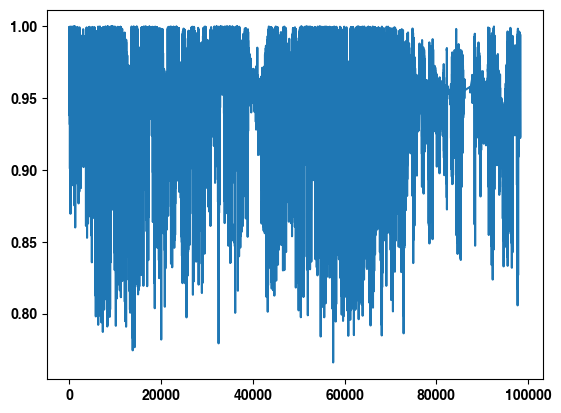

In [137]:
data_ena['SSA_B'].plot()

In [ ]:

# # Apply function to remove outliers
# data_ena = data_ena[data_ena['CCN'] >0]
# data_ena = data_ena[data_ena['AE_BG'] >0]
# data_ena = data_ena[data_ena['AE_BR'] >0]
# data_ena = data_ena[data_ena['AE_GR'] >0]
# data_ena = data_ena[data_ena['BA_B'] >0]
# data_ena = data_ena[data_ena['BA_G'] >0]
# data_ena = data_ena[data_ena['BA_R'] >0]
# data_ena = data_ena[data_ena['SSA_B'] <1]
# data_ena = data_ena[data_ena['SSA_G'] <1]
# data_ena = data_ena[data_ena['SSA_R'] <1]
# data = data.loc[0:456806,:]# The first 200,000 groups of data in the sgp
# data_ena = data_ena.sample(n=200000, random_state=2024)
# Prepare features and target variable
X_ena = data_ena.drop('CCN', axis=1)  # Features
y_ena = data_ena['CCN']  # Features
X_train_ena, X_test_ena, y_train_ena, y_test_ena = train_test_split(X_ena, y_ena, test_size=0.2, random_state=2024)
# Randomly select 3000 samples for SHAP analysis
np.random.seed(2024)
indices = np.random.choice(X_test_ena.shape[0], 3000, replace=False)
# selected_X_test = X_test  # Comment this out if using the random subset
selected_X_test = X_test_ena.iloc[indices]
# summary
import os
plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams['font.weight'] = 'bold'
shap.summary_plot(
    shap_values_ena,
    selected_X_test,
    feature_names=feature_names,
    show=False,
    color_bar=False
)
# shap.summary_plot(shap_values_ena, selected_X_test, show=False,color_bar=False)
cbar = plt.colorbar(aspect=35)
cbar.set_label('Feature value',size=18,fontname='Helvetica', fontweight='bold')
cbar.ax.set_yticklabels([])
cbar.ax.tick_params(axis='y', which='both', length=0)
cbar.ax.text(1.3,0,'Low',va='bottom',ha='left',transform=cbar.ax.transAxes,fontsize=16)
cbar.ax.text(1.3,1,'High',va='top',ha='left',transform=cbar.ax.transAxes,fontsize=16)

plt.xlabel('SHAP value(impact on model output)',fontsize=18,fontname='Helvetica', fontweight='bold')
plt.tick_params(axis='x',labelsize=16)
plt.tick_params(axis='y',labelsize=16)
plt.title('(d)', loc='left', fontsize=18, fontname='Helvetica', fontweight='bold')
plt.title('ENA', fontsize=18, fontname='Helvetica', fontweight='bold')
plt.savefig('E:/aabc/summary/fig-250416/shap-ena.png',dpi=300,bbox_inches='tight',pad_inches=0)
plt.show()


In [ ]:
# save
shap_values_df_ena = pd.DataFrame(shap_values_ena, columns=X_train_ena.columns)

shap_values_df_ena
shap_values_df_ena.to_csv('E:/aabc\myDeepTree\data-250415/ena/enashap_values.csv', index=False)

feature_importance_ena = np.abs(shap_values_df_ena).mean().sort_values(ascending=False)
feature_importance_ena.to_csv('E:/aabc\myDeepTree\data-250415/ena/enafeature_importance.csv')
total_shap_ena = feature_importance_ena.sum()

# contribution_ratio
feature_contribution_ratio_ena = (feature_importance_ena / total_shap_ena) * 100

feature_contribution_ratio_ena.to_csv('E:/aabc\myDeepTree\data-250415/ena/enafeature_contribution_ratio.csv')
feature_contribution_ratio_ena

AE_BR    22.808486
BS_B     16.016819
BA_G     11.950578
AE_BG    11.918759
AE_GR     7.333005
BBS_G     5.641926
BA_B      4.290920
BBS_B     3.128623
SSA_B     3.048852
BS_G      2.846368
SSA_G     2.113208
BA_R      1.827346
BSF_G     1.758132
BBS_R     1.565733
SSA_R     1.014998
BS_R      0.919203
BSF_R     0.918865
BSF_B     0.898178
dtype: float64

In [135]:

data_asi = pd.read_csv('E:/aabc\myDeepTree\data-250415/asi.csv')
data_asi = data_asi.replace(-9999, float('nan'))
data_asi.iloc[:, 0] = pd.to_numeric(data_asi.iloc[:, 0], errors='coerce')
data_asi = data_asi.dropna()
data_asi.columns = [
    'CCN', 'BS_B', 'BS_G', 'BS_R', 'AE_BG', 'AE_BR', 'AE_GR', 'BBS_B', 'BBS_G', 'BBS_R',
    'BSF_B', 'BSF_G', 'BSF_R',  'SSA_B', 'SSA_G', 'SSA_R', 
      'BA_B', 'BA_G', 'BA_R'
]
data_asi = data_asi[data_asi['CCN'] >0]
# data_asi = data_asi[data_asi['h'] <1]
data_asi = data_asi[data_asi['AE_BG'] >0]
data_asi = data_asi[data_asi['AE_BR'] >0]
data_asi = data_asi[data_asi['AE_GR'] >0]
data_asi = data_asi[data_asi['BA_B'] >0]
data_asi = data_asi[data_asi['BA_G'] >0]
data_asi = data_asi[data_asi['BA_R'] >0]
data_asi = data_asi[data_asi['BS_B'] >0]
data_asi = data_asi[data_asi['BS_G'] >0]
data_asi = data_asi[data_asi['BS_R'] >0]
data_asi = data_asi[data_asi['BBS_B'] >0]
data_asi = data_asi[data_asi['BBS_G'] >0]
data_asi = data_asi[data_asi['BBS_R'] >0]
data_asi = data_asi[data_asi['BSF_B'] >0]
data_asi = data_asi[data_asi['BSF_G'] >0]   
data_asi = data_asi[data_asi['BSF_R'] >0]
data_asi = data_asi[data_asi['SSA_B'] <1]
data_asi = data_asi[data_asi['SSA_G'] <1]
data_asi = data_asi[data_asi['SSA_R'] <1]
data_asi = data_asi[data_asi['SSA_B'] >0]
data_asi = data_asi[data_asi['SSA_G'] >0]
data_asi = data_asi[data_asi['SSA_R'] >0]
def remove_outliers(df):
    # Remove outliers using the 3-sigma rule
    for column in df.columns:
        mean = df[column].mean()
        std = df[column].std()
        cutoff = std * 3
        lower = mean - cutoff
        upper = mean + cutoff
        df = df[(df[column] > lower) & (df[column] < upper)]
    return df

# Apply function to remove outliers
data_asi = remove_outliers(data_asi)

data_asi

,CCN,BS_B,BS_G,BS_R,AE_BG,AE_BR,AE_GR,BBS_B,BBS_G,BBS_R,BSF_B,BSF_G,BSF_R,SSA_B,SSA_G,SSA_R,BA_B,BA_G,BA_R
1,99.866000,23.375761,22.696941,20.890125,0.224779,0.349093,0.452534,3.506959,3.079141,3.168227,0.150025,0.135663,0.151661,0.978253,0.981265,0.983799,0.923225,0.826057,0.707971
2,96.089167,21.505592,21.363607,18.998453,0.050527,0.406966,0.703559,2.714427,2.553211,2.777568,0.126220,0.119512,0.146200,0.950047,0.953130,0.949358,1.520157,1.438961,1.365382
3,96.167167,19.118690,18.185902,16.474014,0.381528,0.452928,0.512339,2.464471,2.417343,2.337645,0.128904,0.132924,0.141899,0.944280,0.942133,0.938591,1.479760,1.454632,1.388140
4,95.601167,15.857728,14.828381,13.630428,0.511916,0.446571,0.392197,1.381179,1.378797,1.677934,0.087098,0.092984,0.123102,0.974986,0.975753,0.976643,0.683579,0.628171,0.566406
6,65.715385,9.700858,9.682875,8.276752,0.014152,0.526901,0.953558,1.075042,1.247765,1.257902,0.110819,0.128863,0.151980,0.985185,0.988834,0.988806,0.308841,0.273357,0.236302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485048,0.373828,8.431938,6.773862,3.999436,1.670089,2.296070,2.816948,1.126593,1.193067,0.927468,0.133610,0.176128,0.231900,0.844806,0.841283,0.794991,1.746308,1.439267,1.137069
485049,0.567981,8.952989,6.936341,4.172319,1.946648,2.323871,2.637758,1.054484,0.794995,0.509370,0.117780,0.114613,0.122083,0.859341,0.851866,0.816160,1.669551,1.367980,1.045255
485050,0.485132,8.518941,6.414651,3.706067,2.163990,2.528604,2.831999,0.485955,0.739108,0.929532,0.057044,0.115222,0.250813,0.849920,0.839433,0.790281,1.702796,1.380826,1.082406
485051,0.350301,7.881830,6.565426,4.074286,1.393877,2.040656,2.578840,0.680449,0.940279,0.706358,0.086331,0.143217,0.173370,0.842907,0.843351,0.815168,1.653102,1.374429,1.026733


<Axes: >

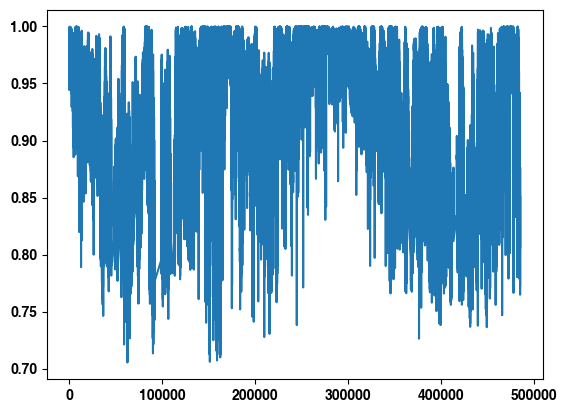

In [138]:
data_asi['SSA_B'].plot()

In [ ]:

# Prepare features and target variable
X_asi = data_asi.drop('CCN', axis=1)  # Features
y_asi = data_asi['CCN']  # Features
X_train_asi, X_test_asi, y_train_asi, y_test_asi = train_test_split(X_asi, y_asi, test_size=0.2, random_state=2024)
# Randomly select 3000 samples for SHAP analysis
np.random.seed(2024)
indices = np.random.choice(X_test_asi.shape[0], 3000, replace=False)
# selected_X_test = X_test  # Comment this out if using the random subset
selected_X_test = X_test_asi.iloc[indices]
# summary
import os
plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams['font.weight'] = 'bold'
shap.summary_plot(
    shap_values_asi,
    selected_X_test,
    feature_names=feature_names,
    show=False,
    color_bar=False
)
# shap.summary_plot(shap_values_asi, selected_X_test, show=False,color_bar=False)
cbar = plt.colorbar(aspect=35)
cbar.set_label('Feature value',size=18,fontname='Helvetica', fontweight='bold')
cbar.ax.set_yticklabels([])
cbar.ax.tick_params(axis='y', which='both', length=0)
cbar.ax.text(1.3,0,'Low',va='bottom',ha='left',transform=cbar.ax.transAxes,fontsize=16)
cbar.ax.text(1.3,1,'High',va='top',ha='left',transform=cbar.ax.transAxes,fontsize=16)

plt.xlabel('SHAP value(impact on model output)',fontsize=18,fontname='Helvetica', fontweight='bold')
plt.tick_params(axis='x',labelsize=16)
plt.tick_params(axis='y',labelsize=16)
plt.title('(d)', loc='left', fontsize=18, fontname='Helvetica', fontweight='bold')
plt.title('ASI', fontsize=18, fontname='Helvetica', fontweight='bold')
# plt.savefig('E:/aabc/summary/fig-250416/shap-asi.png',dpi=300,bbox_inches='tight',pad_inches=0)
plt.show()


In [114]:
# save
shap_values_df_asi = pd.DataFrame(shap_values_asi, columns=X_train_asi.columns)

shap_values_df_asi
shap_values_df_asi.to_csv('E:/aabc\myDeepTree\data-250415/asi/asishap_values.csv', index=False)

feature_importance_asi = np.abs(shap_values_df_asi).mean().sort_values(ascending=False)
feature_importance_asi.to_csv('E:/aabc\myDeepTree\data-250415/asi/asifeature_importance.csv')
total_shap_asi = feature_importance_asi.sum()

# contribution_ratio
feature_contribution_ratio_asi = (feature_importance_asi / total_shap_asi) * 100

feature_contribution_ratio_asi.to_csv('E:/aabc\myDeepTree\data-250415/asi/asifeature_contribution_ratio.csv')
feature_contribution_ratio_asi

AE_BG    14.969868
AE_BR    13.636029
BS_B     13.154715
BA_B     11.519359
BBS_G     9.560298
BBS_B     7.618062
SSA_B     4.616874
AE_GR     4.530444
SSA_G     3.839891
SSA_R     3.702283
BA_R      3.351972
BS_G      2.809939
BA_G      2.517767
BBS_R     1.670588
BSF_R     0.834211
BSF_G     0.656071
BS_R      0.583922
BSF_B     0.427707
dtype: float64

In [156]:

data_mos = pd.read_csv('E:/aabc\myDeepTree\data-250415/ba_qc/mos.csv')
data_mos = data_mos.replace(-9999, float('nan'))
data_mos.iloc[:, 0] = pd.to_numeric(data_mos.iloc[:, 0], errors='coerce')
data_mos = data_mos.dropna()
data_mos.columns = [
    'CCN', 'BS_B', 'BS_G', 'BS_R', 'AE_BG', 'AE_BR', 'AE_GR', 'BBS_B', 'BBS_G', 'BBS_R',
    'BSF_B', 'BSF_G', 'BSF_R',  'SSA_B', 'SSA_G', 'SSA_R', 
     'BA_B', 'BA_G', 'BA_R'
]
data_mos = data_mos[data_mos['CCN'] >0]
# data_mos = data_mos[data_mos['h'] <1]
data_mos = data_mos[data_mos['AE_BG'] >0]
data_mos = data_mos[data_mos['AE_BR'] >0]
data_mos = data_mos[data_mos['AE_GR'] >0]
data_mos = data_mos[data_mos['BA_B'] >0]
data_mos = data_mos[data_mos['BA_G'] >0]
data_mos = data_mos[data_mos['BA_R'] >0]
data_mos = data_mos[data_mos['BS_B'] >0]
data_mos = data_mos[data_mos['BS_G'] >0]
data_mos = data_mos[data_mos['BS_R'] >0]
data_mos = data_mos[data_mos['BBS_B'] >0]
data_mos = data_mos[data_mos['BBS_G'] >0]
data_mos = data_mos[data_mos['BBS_R'] >0]
data_mos = data_mos[data_mos['BSF_B'] >0]
data_mos = data_mos[data_mos['BSF_G'] >0]   
data_mos = data_mos[data_mos['BSF_R'] >0]
data_mos = data_mos[data_mos['SSA_B'] <1]
data_mos = data_mos[data_mos['SSA_G'] <1]
data_mos = data_mos[data_mos['SSA_R'] <1]
data_mos = data_mos[data_mos['SSA_B'] >0]
data_mos = data_mos[data_mos['SSA_G'] >0]
data_mos = data_mos[data_mos['SSA_R'] >0]
def remove_outliers(df):
    # Remove outliers using the 3-sigma rule
    for column in df.columns:
        mean = df[column].mean()
        std = df[column].std()
        cutoff = std * 3
        lower = mean - cutoff
        upper = mean + cutoff
        df = df[(df[column] > lower) & (df[column] < upper)]
    return df

# Apply function to remove outliers
data_mos = remove_outliers(data_mos)

data_mos

,CCN,BS_B,BS_G,BS_R,AE_BG,AE_BR,AE_GR,BBS_B,BBS_G,BBS_R,BSF_B,BSF_G,BSF_R,SSA_B,SSA_G,SSA_R,BA_B,BA_G,BA_R
4,8.424491,2.809753,1.931216,1.608535,2.859919,1.536884,0.435989,0.209039,0.122928,0.084352,0.074398,0.063653,0.052440,0.948364,0.930665,0.974991,0.152984,0.143877,0.041260
5,9.222334,3.185798,2.718422,2.384818,1.210119,0.828621,0.511178,0.302375,0.246301,0.120632,0.094914,0.090604,0.050583,0.915995,0.912672,0.909333,0.292167,0.260108,0.237783
6,8.094605,2.536240,1.954422,1.359184,1.987647,1.854203,1.743164,0.318253,0.183288,0.089292,0.125482,0.093781,0.065695,0.912082,0.892419,0.881988,0.244475,0.235605,0.181862
7,7.586641,3.795401,3.234736,2.842074,1.219205,0.826527,0.499779,0.564524,0.461582,0.215887,0.148739,0.142696,0.075961,0.934279,0.939310,0.931251,0.266984,0.209000,0.209813
8,9.176097,5.056887,4.085558,3.092067,1.626897,1.455526,1.312928,0.497479,0.365003,0.302081,0.098377,0.089340,0.097696,0.949376,0.952231,0.966357,0.269647,0.204955,0.107647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55158,91.488164,8.898543,7.227823,5.292771,1.586144,1.552070,1.523718,1.056179,0.777807,0.446299,0.118691,0.107613,0.084322,0.972910,0.968063,0.968539,0.247776,0.238447,0.171924
55159,87.639045,9.236236,7.309640,5.094836,1.784389,1.780761,1.777741,0.724802,0.624752,0.506086,0.078474,0.085470,0.099333,0.980407,0.977673,0.972922,0.184584,0.166930,0.141797
55160,87.423026,8.787906,6.996405,4.977571,1.738926,1.697724,1.663440,0.870891,0.666957,0.531150,0.099101,0.095328,0.106709,0.977157,0.973142,0.973341,0.205433,0.193097,0.136332
55161,91.194864,9.451076,7.680676,5.325417,1.582113,1.732579,1.857783,0.908264,0.788672,0.580944,0.096102,0.102683,0.109089,0.972535,0.969541,0.963108,0.266905,0.241294,0.203989


<Axes: >

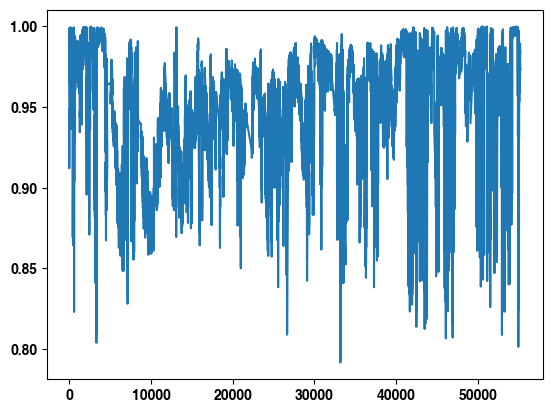

In [154]:
data_mos['SSA_B'].plot()

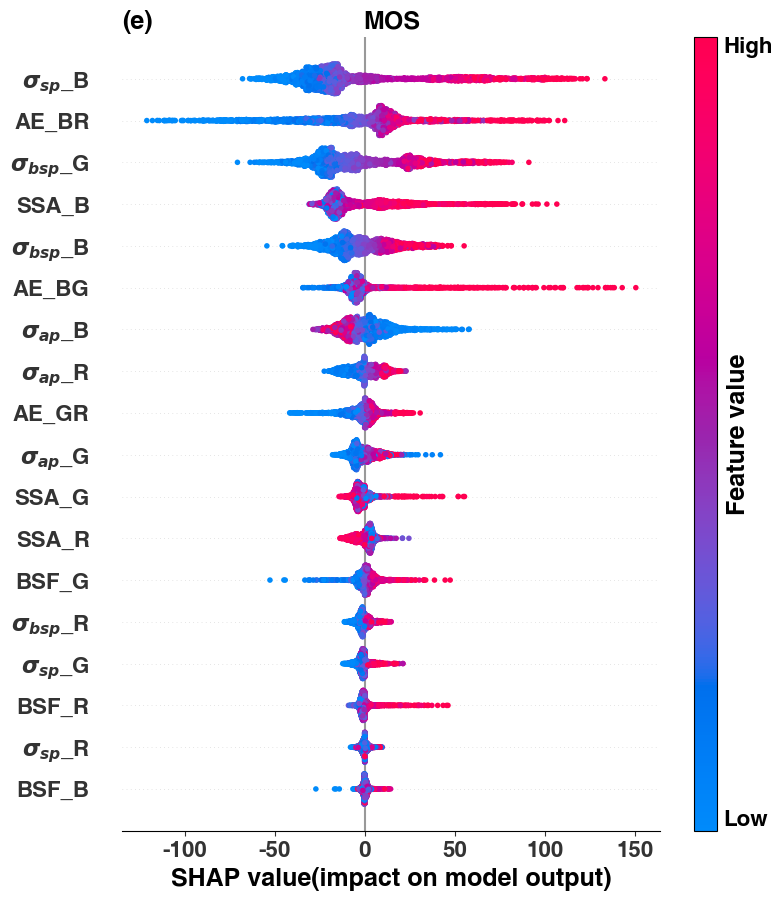

In [155]:

# Prepare features and target variable
X_mos = data_mos.drop('CCN', axis=1)  # Features
y_mos = data_mos['CCN']  # Features
X_train_mos, X_test_mos, y_train_mos, y_test_mos = train_test_split(X_mos, y_mos, test_size=0.2, random_state=2024)
# Randomly select 3000 samples for SHAP analysis
np.random.seed(2024)
indices = np.random.choice(X_test_mos.shape[0], 3000, replace=False)
# selected_X_test = X_test  # Comment this out if using the random subset
selected_X_test = X_test_mos.iloc[indices]
# summary
import os
plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams['font.weight'] = 'bold'
shap.summary_plot(
    shap_values_mos,
    selected_X_test,
    feature_names=feature_names,
    show=False,
    color_bar=False
)
# shap.summary_plot(shap_values_mos, selected_X_test, show=False,color_bar=False)
cbar = plt.colorbar(aspect=35)
cbar.set_label('Feature value',size=18,fontname='Helvetica', fontweight='bold')
cbar.ax.set_yticklabels([])
cbar.ax.tick_params(axis='y', which='both', length=0)
cbar.ax.text(1.3,0,'Low',va='bottom',ha='left',transform=cbar.ax.transAxes,fontsize=16)
cbar.ax.text(1.3,1,'High',va='top',ha='left',transform=cbar.ax.transAxes,fontsize=16)

plt.xlabel('SHAP value(impact on model output)',fontsize=18,fontname='Helvetica', fontweight='bold')
plt.tick_params(axis='x',labelsize=16)
plt.tick_params(axis='y',labelsize=16)
plt.title('(e)', loc='left', fontsize=18, fontname='Helvetica', fontweight='bold')
plt.title('MOS', fontsize=18, fontname='Helvetica', fontweight='bold')
# plt.savefig('E:/aabc/summary/fig-250416/shap-mos.png',dpi=300,bbox_inches='tight',pad_inches=0)
plt.show()


In [72]:
# save
shap_values_df_mos = pd.DataFrame(shap_values_mos, columns=X_train_mos.columns)

shap_values_df_mos
shap_values_df_mos.to_csv('E:/aabc\myDeepTree\data-250415/ba_qc/mos/mosshap_values.csv', index=False)

feature_importance_mos = np.abs(shap_values_df_mos).mean().sort_values(ascending=False)
feature_importance_mos.to_csv('E:/aabc\myDeepTree\data-250415/ba_qc/mos/mosfeature_importance.csv')
total_shap_mos = feature_importance_mos.sum()

# contribution_ratio
feature_contribution_ratio_mos = (feature_importance_mos / total_shap_mos) * 100

feature_contribution_ratio_mos.to_csv('E:/aabc\myDeepTree\data-250415/ba_qc/mos/mosfeature_contribution_ratio.csv')
feature_contribution_ratio_mos

BS_B     18.853453
AE_BR    14.340790
BBS_G    13.637706
SSA_B    10.286697
BBS_B     8.036067
AE_BG     6.025866
BA_B      5.516881
BA_R      4.015515
AE_GR     3.363535
BA_G      3.237391
SSA_G     2.257014
SSA_R     2.183807
BSF_G     2.143843
BBS_R     1.675607
BS_G      1.644355
BSF_R     1.275323
BS_R      0.842176
BSF_B     0.663975
dtype: float64

In [166]:
sgph = pd.read_csv(r'E:\aabc\myDeepTree\data-250415/ba_qc\sgph/sgphfeature_contribution_ratio.csv')# activation rate
enah = pd.read_csv(r'E:/aabc\myDeepTree\data-250415/ba_qc/enah/enahfeature_contribution_ratio.csv')# activation rate
guch = pd.read_csv(r'E:/aabc\myDeepTree\data-250415/ba_qc/guch/guchfeature_contribution_ratio.csv')# activation rate
asih = pd.read_csv(r'E:/aabc\myDeepTree\data-250415/ba_qc/asih/asihfeature_contribution_ratio.csv')# activation rate
mosh = pd.read_csv(r'E:/aabc\myDeepTree\data-250415/ba_qc/mosh/moshfeature_contribution_ratio.csv')# activation rate
sgp = pd.read_csv(r'E:/aabc\myDeepTree\data-250415/ba_qc/sgp/sgpfeature_contribution_ratio.csv')
ena = pd.read_csv(r'E:/aabc\myDeepTree\data-250415/ba_qc/ena/enafeature_contribution_ratio.csv')
asi = pd.read_csv(r'E:/aabc\myDeepTree\data-250415/ba_qc/asi/asifeature_contribution_ratio.csv')
guc = pd.read_csv(r'E:/aabc\myDeepTree\data-250415/ba_qc/guc/gucfeature_contribution_ratio.csv')
mos = pd.read_csv(r'E:/aabc\myDeepTree\data-250415/ba_qc/mos/mosfeature_contribution_ratio.csv')
guc

,Unnamed: 0,0
0,BBS_B,18.170615
1,BBS_G,10.733571
2,BSF_G,10.447783
3,BA_R,8.482264
4,BA_B,7.349590
5,AE_BR,6.605294
6,BSF_B,6.096936
7,BS_B,6.076529
8,AE_BG,5.670513
9,SSA_B,3.986258


In [167]:
# Extract variable names and corresponding values from the DataFrame
variable_names_guc = guc.iloc[:, 0].values
variable_values_guc = guc.iloc[:, 1].values

variable_dict_guc = dict(zip(variable_names_guc, variable_values_guc))

variable_names_sgp = sgp.iloc[:, 0].values
variable_values_sgp = sgp.iloc[:, 1].values

variable_dict_sgp = dict(zip(variable_names_sgp, variable_values_sgp))

variable_names_ena = ena.iloc[:, 0].values
variable_values_ena = ena.iloc[:, 1].values

variable_dict_ena = dict(zip(variable_names_ena, variable_values_ena))

variable_names_asi = asi.iloc[:, 0].values
variable_values_asi = asi.iloc[:, 1].values

variable_dict_asi = dict(zip(variable_names_asi, variable_values_asi))

variable_names_mos = mos.iloc[:, 0].values
variable_values_mos = mos.iloc[:, 1].values

variable_dict_mos = dict(zip(variable_names_mos, variable_values_mos))

variable_names_guch = guch.iloc[:, 0].values
variable_values_guch = guch.iloc[:, 1].values

variable_dict_guch = dict(zip(variable_names_guch, variable_values_guch))

variable_names_sgph = sgph.iloc[:, 0].values
variable_values_sgph = sgph.iloc[:, 1].values

variable_dict_sgph = dict(zip(variable_names_sgph, variable_values_sgph))

variable_names_enah = enah.iloc[:, 0].values
variable_values_enah = enah.iloc[:, 1].values

variable_dict_enah = dict(zip(variable_names_enah, variable_values_enah))

variable_names_asih = asih.iloc[:, 0].values
variable_values_asih = asih.iloc[:, 1].values

variable_dict_asih = dict(zip(variable_names_asih, variable_values_asih))

variable_names_mosh = mosh.iloc[:, 0].values
variable_values_mosh = mosh.iloc[:, 1].values

variable_dict_mosh = dict(zip(variable_names_mosh, variable_values_mosh))
variable_dict_asi

{'BS_B': 22.242863342407336,
 'BBS_B': 12.66212210635444,
 'AE_BR': 12.50348244782917,
 'AE_BG': 11.758446001183426,
 'BA_B': 7.164318227820416,
 'BBS_G': 6.8694183153742925,
 'BA_R': 4.273389587409574,
 'SSA_R': 4.2487628481351685,
 'AE_GR': 4.020655566493243,
 'SSA_B': 3.508655218029353,
 'SSA_G': 2.9177595296875367,
 'BS_G': 2.3674057858509765,
 'BBS_R': 1.2798827173399574,
 'BSF_R': 1.1251187551397488,
 'BA_G': 1.0671741365950334,
 'BSF_G': 0.9972795854776384,
 'BS_R': 0.678182311364582,
 'BSF_B': 0.315083517508106}

In [168]:
AE_ASI=variable_dict_asi['AE_BG']+variable_dict_asi['AE_BR']+variable_dict_asi['AE_GR']
BS_ASI=variable_dict_asi['BS_B']+variable_dict_asi['BS_G']+variable_dict_asi['BS_R']
BA_ASI=variable_dict_asi['BA_B']+variable_dict_asi['BA_G']+variable_dict_asi['BA_R']
BBS_ASI=variable_dict_asi['BBS_B']+variable_dict_asi['BBS_G']+variable_dict_asi['BBS_R']
SSA_ASI=variable_dict_asi['SSA_B']+variable_dict_asi['SSA_G']+variable_dict_asi['SSA_R']
# G_ASI=variable_dict_asi['g_B']+variable_dict_asi['g_G']+variable_dict_asi['g_R']
BSF_ASI=variable_dict_asi['BSF_B']+variable_dict_asi['BSF_G']+variable_dict_asi['BSF_R']
# TRAN_ASI=variable_dict_asi['TR_B']+variable_dict_asi['TR_G']+variable_dict_asi['TR_R']
# T_ASI=variable_dict_asi['T_Neph_Dry']
# RH_ASI=variable_dict_asi['RH']
# P_ASI=variable_dict_asi['P_Neph_Dry']

AE_ENA=variable_dict_ena['AE_BG']+variable_dict_ena['AE_BR']+variable_dict_ena['AE_GR']
BS_ENA=variable_dict_ena['BS_B']+variable_dict_ena['BS_G']+variable_dict_ena['BA_R']
BA_ENA=variable_dict_ena['BA_B']+variable_dict_ena['BA_G']+variable_dict_ena['BA_R']
BBS_ENA=variable_dict_ena['BBS_B']+variable_dict_ena['BBS_G']+variable_dict_ena['BBS_R']
SSA_ENA=variable_dict_ena['SSA_B']+variable_dict_ena['SSA_G']+variable_dict_ena['SSA_R']
# G_ENA=variable_dict_ena['g_B']+variable_dict_ena['g_G']+variable_dict_ena['g_R']
BSF_ENA=variable_dict_ena['BSF_B']+variable_dict_ena['BSF_G']+variable_dict_ena['BSF_R']
# TRAN_ENA=variable_dict_ena['TR_B']+variable_dict_ena['TR_G']+variable_dict_ena['TR_R']
# T_ENA=variable_dict_ena['T_Neph_Dry']
# RH_ENA=variable_dict_ena['RH']
# P_ENA=variable_dict_ena['P_Neph_Dry']

AE_SGP=variable_dict_sgp['AE_BG']+variable_dict_sgp['AE_BR']+variable_dict_sgp['AE_GR']
BS_SGP=variable_dict_sgp['BS_B']+variable_dict_sgp['BS_G']+variable_dict_sgp['BS_R']
BA_SGP=variable_dict_sgp['BA_B']+variable_dict_sgp['BA_G']+variable_dict_sgp['BA_R']
BBS_SGP=variable_dict_sgp['BBS_B']+variable_dict_sgp['BBS_G']+variable_dict_sgp['BBS_R']
SSA_SGP=variable_dict_sgp['SSA_B']+variable_dict_sgp['SSA_G']+variable_dict_sgp['SSA_R']
# G_SGP=variable_dict_sgp['g_B']+variable_dict_sgp['g_G']+variable_dict_sgp['g_R']
BSF_SGP=variable_dict_sgp['BSF_B']+variable_dict_sgp['BSF_G']+variable_dict_sgp['BSF_R']
# TRAN_SGP=variable_dict_sgp['TR_B']+variable_dict_sgp['TR_G']+variable_dict_sgp['TR_R']
# T_SGP=variable_dict_sgp['T_Neph_Dry']
# RH_SGP=variable_dict_sgp['RH']
# P_SGP=variable_dict_sgp['P_Neph_Dry']

AE_GUC=variable_dict_guc['AE_BG']+variable_dict_guc['AE_BR']+variable_dict_guc['AE_GR']
BS_GUC=variable_dict_guc['BS_B']+variable_dict_guc['BS_G']+variable_dict_guc['BS_R']
BA_GUC=variable_dict_guc['BA_B']+variable_dict_guc['BA_G']+variable_dict_guc['BA_R']
BBS_GUC=variable_dict_guc['BBS_B']+variable_dict_guc['BBS_G']+variable_dict_guc['BBS_R']
SSA_GUC=variable_dict_guc['SSA_B']+variable_dict_guc['SSA_G']+variable_dict_guc['SSA_R']
# G_GUC=variable_dict_guc['g_B']+variable_dict_guc['g_G']+variable_dict_guc['g_R']
BSF_GUC=variable_dict_guc['BSF_B']+variable_dict_guc['BSF_G']+variable_dict_guc['BSF_R']
# TRAN_GUC=variable_dict_guc['TR_B']+variable_dict_guc['TR_G']+variable_dict_guc['TR_R']
# T_GUC=variable_dict_guc['T_Neph_Dry']
# RH_GUC=variable_dict_guc['RH']
# P_GUC=variable_dict_guc['P_Neph_Dry']



In [169]:
AE_mos=variable_dict_mos['AE_BG']+variable_dict_mos['AE_BR']+variable_dict_mos['AE_GR']
BS_mos=variable_dict_mos['BS_B']+variable_dict_mos['BS_G']+variable_dict_mos['BS_R']
BA_mos=variable_dict_mos['BA_B']+variable_dict_mos['BA_G']+variable_dict_mos['BA_R']
BBS_mos=variable_dict_mos['BBS_B']+variable_dict_mos['BBS_G']+variable_dict_mos['BBS_R']
SSA_mos=variable_dict_mos['SSA_B']+variable_dict_mos['SSA_G']+variable_dict_mos['SSA_R']
# G_mos=variable_dict_mos['g_B']+variable_dict_mos['g_G']+variable_dict_mos['g_R']
BSF_mos=variable_dict_mos['BSF_B']+variable_dict_mos['BSF_G']+variable_dict_mos['BSF_R']
# TRAN_mos=variable_dict_mos['TR_B']+variable_dict_mos['TR_G']+variable_dict_mos['TR_R']
# T_mos=variable_dict_mos['T_Neph_Dry']
# RH_mos=variable_dict_mos['RH']
# P_mos=variable_dict_mos['P_Neph_Dry']

In [149]:
AE_ASIh=variable_dict_asih['AE_BG']+variable_dict_asih['AE_BR']+variable_dict_asih['AE_GR']
BS_ASIh=variable_dict_asih['BS_B']+variable_dict_asih['BS_G']+variable_dict_asih['BS_R']
BA_ASIh=variable_dict_asih['BA_B']+variable_dict_asih['BA_G']+variable_dict_asih['BA_R']
BBS_ASIh=variable_dict_asih['BBS_B']+variable_dict_asih['BBS_G']+variable_dict_asih['BBS_R']
SSA_ASIh=variable_dict_asih['SSA_B']+variable_dict_asih['SSA_G']+variable_dict_asih['SSA_R']
# G_ASIh=variable_dict_asih['g_B']+variable_dict_asih['g_G']+variable_dict_asih['g_R']
BSF_ASIh=variable_dict_asih['BSF_B']+variable_dict_asih['BSF_G']+variable_dict_asih['BSF_R']
# TRAN_ASIh=variable_dict_asih['TR_B']+variable_dict_asih['TR_G']+variable_dict_asih['TR_R']
# T_ASIh=variable_dict_asih['T_Neph_Dry']
# RH_ASIh=variable_dict_asih['RH']
# P_ASIh=variable_dict_asih['P_Neph_Dry']

AE_ENAh=variable_dict_enah['AE_BG']+variable_dict_enah['AE_BR']+variable_dict_enah['AE_GR']
BS_ENAh=variable_dict_enah['BS_B']+variable_dict_enah['BS_G']+variable_dict_enah['BA_R']
BA_ENAh=variable_dict_enah['BA_B']+variable_dict_enah['BA_G']+variable_dict_enah['BA_R']
BBS_ENAh=variable_dict_enah['BBS_B']+variable_dict_enah['BBS_G']+variable_dict_enah['BBS_R']
SSA_ENAh=variable_dict_enah['SSA_B']+variable_dict_enah['SSA_G']+variable_dict_enah['SSA_R']
# G_ENAh=variable_dict_enah['g_B']+variable_dict_enah['g_G']+variable_dict_enah['g_R']
BSF_ENAh=variable_dict_enah['BSF_B']+variable_dict_enah['BSF_G']+variable_dict_enah['BSF_R']
# TRAN_ENAh=variable_dict_enah['TR_B']+variable_dict_enah['TR_G']+variable_dict_enah['TR_R']
# T_ENAh=variable_dict_enah['T_Neph_Dry']
# RH_ENAh=variable_dict_enah['RH']
# P_ENAh=variable_dict_enah['P_Neph_Dry']

AE_SGPh=variable_dict_sgph['AE_BG']+variable_dict_sgph['AE_BR']+variable_dict_sgph['AE_GR']
BS_SGPh=variable_dict_sgph['BS_B']+variable_dict_sgph['BS_G']+variable_dict_sgph['BS_R']
BA_SGPh=variable_dict_sgph['BA_B']+variable_dict_sgph['BA_G']+variable_dict_sgph['BA_R']
BBS_SGPh=variable_dict_sgph['BBS_B']+variable_dict_sgph['BBS_G']+variable_dict_sgph['BBS_R']
SSA_SGPh=variable_dict_sgph['SSA_B']+variable_dict_sgph['SSA_G']+variable_dict_sgph['SSA_R']
# G_SGPh=variable_dict_sgph['g_B']+variable_dict_sgph['g_G']+variable_dict_sgph['g_R']
BSF_SGPh=variable_dict_sgph['BSF_B']+variable_dict_sgph['BSF_G']+variable_dict_sgph['BSF_R']
# TRAN_SGPh=variable_dict_sgph['TR_B']+variable_dict_sgph['TR_G']+variable_dict_sgph['TR_R']
# T_SGPh=variable_dict_sgph['T_Neph_Dry']
# RH_SGPh=variable_dict_sgph['RH']
# P_SGPh=variable_dict_sgph['P_Neph_Dry']

AE_GUCh=variable_dict_guch['AE_BG']+variable_dict_guch['AE_BR']+variable_dict_guch['AE_GR']
BS_GUCh=variable_dict_guch['BS_B']+variable_dict_guch['BS_G']+variable_dict_guch['BS_R']
BA_GUCh=variable_dict_guch['BA_B']+variable_dict_guch['BA_G']+variable_dict_guch['BA_R']
BBS_GUCh=variable_dict_guch['BBS_B']+variable_dict_guch['BBS_G']+variable_dict_guch['BBS_R']
SSA_GUCh=variable_dict_guch['SSA_B']+variable_dict_guch['SSA_G']+variable_dict_guch['SSA_R']
# G_GUCh=variable_dict_guch['g_B']+variable_dict_guch['g_G']+variable_dict_guch['g_R']
BSF_GUCh=variable_dict_guch['BSF_B']+variable_dict_guch['BSF_G']+variable_dict_guch['BSF_R']
# TRAN_GUCh=variable_dict_guch['TR_B']+variable_dict_guch['TR_G']+variable_dict_guch['TR_R']
# T_GUCh=variable_dict_guch['T_Neph_Dry']
# RH_GUCh=variable_dict_guch['RH']
# P_GUCh=variable_dict_guch['P_Neph_Dry']

In [150]:
AE_mosh=variable_dict_mosh['AE_BG']+variable_dict_mosh['AE_BR']+variable_dict_mosh['AE_GR']
BS_mosh=variable_dict_mosh['BS_B']+variable_dict_mosh['BS_G']+variable_dict_mosh['BS_R']
BA_mosh=variable_dict_mosh['BA_B']+variable_dict_mosh['BA_G']+variable_dict_mosh['BA_R']
BBS_mosh=variable_dict_mosh['BBS_B']+variable_dict_mosh['BBS_G']+variable_dict_mosh['BBS_R']
SSA_mosh=variable_dict_mosh['SSA_B']+variable_dict_mosh['SSA_G']+variable_dict_mosh['SSA_R']
# G_mosh=variable_dict_mosh['g_B']+variable_dict_mosh['g_G']+variable_dict_mosh['g_R']
BSF_mosh=variable_dict_mosh['BSF_B']+variable_dict_mosh['BSF_G']+variable_dict_mosh['BSF_R']
# TRAN_mosh=variable_dict_mosh['TR_B']+variable_dict_mosh['TR_G']+variable_dict_mosh['TR_R']
# T_mosh=variable_dict_mosh['T_Neph_Dry']
# RH_mosh=variable_dict_mosh['RH']
# P_mosh=variable_dict_mosh['P_Neph_Dry']

In [ ]:
# gy_ASI = 100-RH_ASI
# gy_SGP = 100-RH_SGP
# gy_ENA = 100-RH_ENA
# gy_GUC = 100-RH_GUC
# gy_mos = 100-RH_mos
# gy_ASIh = 100-RH_ASIh
# gy_SGPh = 100-RH_SGPh
# gy_ENAh = 100-RH_ENAh
# gy_GUCh = 100-RH_GUCh
# gy_mosh = 100-RH_mosh
# AE_ASI=AE_ASI/gy_ASI*100
# BS_ASI=BS_ASI/gy_ASI*100
# BA_ASI=BA_ASI/gy_ASI*100
# BBS_ASI=BBS_ASI/gy_ASI*100
# SSA_ASI=SSA_ASI/gy_ASI*100
# # G_ASI=G_ASI/gy_ASI*100
# BSF_ASI=BSF_ASI/gy_ASI*100
# TRAN_ASI=TRAN_ASI/gy_ASI*100
# T_ASI=variable_dict_asi['T_Neph_Dry']
# RH_ASI=variable_dict_asi['RH']
# P_ASI=variable_dict_asi['P_Neph_Dry']


In [ ]:
# AE_ENA=AE_ENA/gy_ENA*100
# BS_ENA=BS_ENA/gy_ENA*100
# BA_ENA=BA_ENA/gy_ENA*100
# BBS_ENA=BBS_ENA/gy_ENA*100
# SSA_ENA=SSA_ENA/gy_ENA*100
# # G_ENA=G_ENA/gy_ENA*100
# BSF_ENA=BSF_ENA/gy_ENA*100
# # TRAN_ENA=TRAN_ENA/gy_ENA*100

In [ ]:
# AE_SGP=AE_SGP/gy_SGP*100
# BS_SGP=BS_SGP/gy_SGP*100
# BA_SGP=BA_SGP/gy_SGP*100
# BBS_SGP=BBS_SGP/gy_SGP*100
# SSA_SGP=SSA_SGP/gy_SGP*100
# # G_SGP=G_SGP/gy_SGP*100
# BSF_SGP=BSF_SGP/gy_SGP*100
# # TRAN_SGP=TRAN_SGP/gy_SGP*100


In [ ]:
# AE_GUC=AE_GUC/gy_GUC*100
# BS_GUC=BS_GUC/gy_GUC*100
# BA_GUC=BA_GUC/gy_GUC*100
# BBS_GUC=BBS_GUC/gy_GUC*100
# SSA_GUC=SSA_GUC/gy_GUC*100
# # G_GUC=G_GUC/gy_GUC*100
# BSF_GUC=BSF_GUC/gy_GUC*100
# # TRAN_GUC=TRAN_GUC/gy_GUC*100

In [ ]:
# AE_mos=AE_mos/gy_mos*100
# BS_mos=BS_mos/gy_mos*100
# BA_mos=BA_mos/gy_mos*100
# BBS_mos=BBS_mos/gy_mos*100
# SSA_mos=SSA_mos/gy_mos*100
# # G_mos=G_mos/gy_mos*100
# BSF_mos=BSF_mos/gy_mos*100
# # TRAN_mos=TRAN_mos/gy_mos*100

In [ ]:
# AE_GUCh=AE_GUCh/gy_GUCh*100
# BS_GUCh=BS_GUCh/gy_GUCh*100
# BA_GUCh=BA_GUCh/gy_GUCh*100
# BBS_GUCh=BBS_GUCh/gy_GUCh*100
# SSA_GUCh=SSA_GUCh/gy_GUCh*100
# # G_GUCh=G_GUCh/gy_GUCh*100
# BSF_GUCh=BSF_GUCh/gy_GUCh*100
# # TRAN_GUCh=TRAN_GUCh/gy_GUCh*100

In [ ]:
# AE_ASIh=AE_ASIh/gy_ASIh*100
# BS_ASIh=BS_ASIh/gy_ASIh*100
# BA_ASIh=BA_ASIh/gy_ASIh*100
# BBS_ASIh=BBS_ASIh/gy_ASIh*100
# SSA_ASIh=SSA_ASIh/gy_ASIh*100
# # G_ASIh=G_ASIh/gy_ASIh*100
# BSF_ASIh=BSF_ASIh/gy_ASIh*100
# # TRAN_ASIh=TRAN_ASIh/gy_ASIh*100

In [ ]:
# AE_SGPh=AE_SGPh/gy_SGPh*100
# BS_SGPh=BS_SGPh/gy_SGPh*100
# BA_SGPh=BA_SGPh/gy_SGPh*100
# BBS_SGPh=BBS_SGPh/gy_SGPh*100
# SSA_SGPh=SSA_SGPh/gy_SGPh*100
# # G_SGPh=G_SGPh/gy_SGPh*100
# BSF_SGPh=BSF_SGPh/gy_SGPh*100
# # TRAN_SGPh=TRAN_SGPh/gy_SGPh*100

In [ ]:
# AE_ENAh=AE_ENAh/gy_ENAh*100
# BS_ENAh=BS_ENAh/gy_ENAh*100
# BA_ENAh=BA_ENAh/gy_ENAh*100
# BBS_ENAh=BBS_ENAh/gy_ENAh*100
# SSA_ENAh=SSA_ENAh/gy_ENAh*100
# # G_ENAh=G_ENAh/gy_ENAh*100
# BSF_ENAh=BSF_ENAh/gy_ENAh*100
# # TRAN_ENAh=TRAN_ENAh/gy_ENAh*100

In [ ]:
# AE_mosh=AE_mosh/gy_mosh*100
# BS_mosh=BS_mosh/gy_mosh*100
# BA_mosh=BA_mosh/gy_mosh*100
# BBS_mosh=BBS_mosh/gy_mosh*100
# SSA_mosh=SSA_mosh/gy_mosh*100
# # G_mosh=G_mosh/gy_mosh*100
# BSF_mosh=BSF_mosh/gy_mosh*100
# # TRAN_mosh=TRAN_mosh/gy_mosh*100

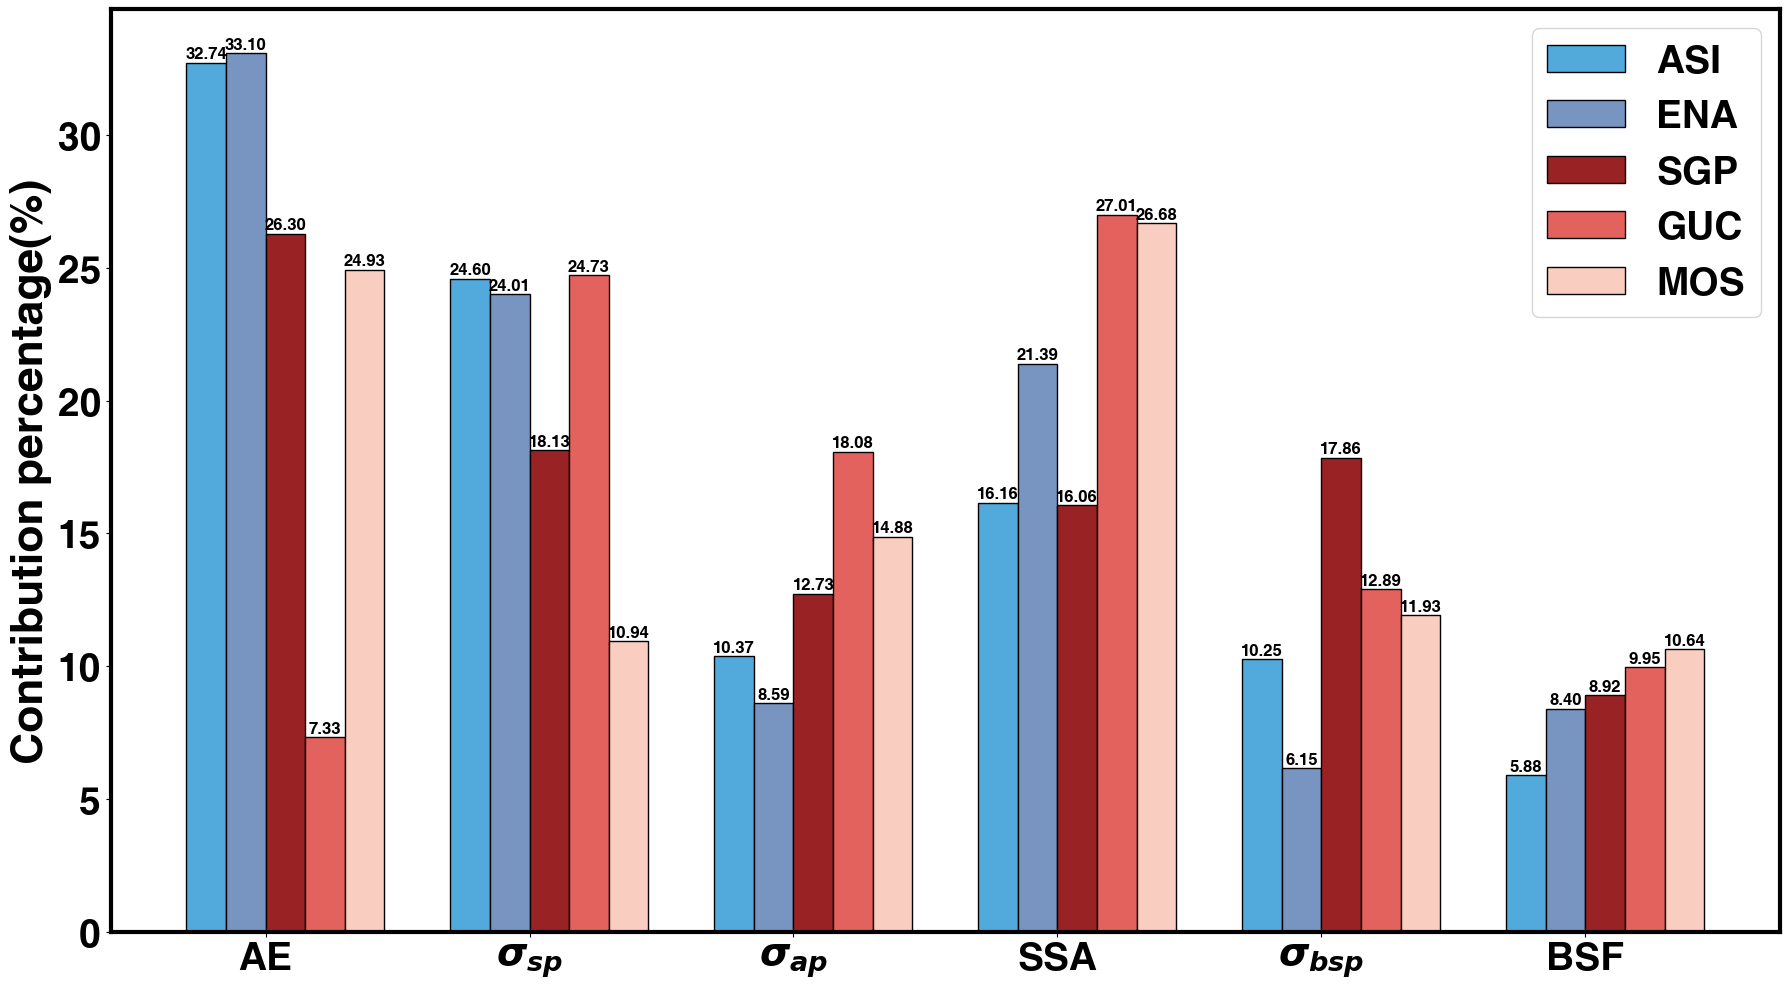

In [151]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(18, 10)) 

# values_grouped = [
#     (AE_ASI, BS_ASI, BA_ASI, SSA_ASI,  BBS_ASI,  BSF_ASI),
#     (AE_ENA, BS_ENA, BA_ENA, SSA_ENA,  BBS_ENA,  BSF_ENA),
#     (AE_SGP, BS_SGP, BA_SGP, SSA_SGP,  BBS_SGP,  BSF_SGP),
#     (AE_GUC, BS_GUC, BA_GUC, SSA_GUC,  BBS_GUC,  BSF_GUC),
#     (AE_mos, BS_mos, BA_mos, SSA_mos,  BBS_mos,  BSF_mos)
# ]
values_grouped = [
    (AE_ASIh, BS_ASIh, BA_ASIh, SSA_ASIh,  BBS_ASIh,  BSF_ASIh),
    (AE_ENAh, BS_ENAh, BA_ENAh, SSA_ENAh,  BBS_ENAh,  BSF_ENAh),
    (AE_SGPh, BS_SGPh, BA_SGPh, SSA_SGPh,  BBS_SGPh,  BSF_SGPh),
    (AE_GUCh, BS_GUCh, BA_GUCh, SSA_GUCh,  BBS_GUCh,  BSF_GUCh),
    (AE_mosh, BS_mosh, BA_mosh, SSA_mosh,  BBS_mosh,  BSF_mosh)
]

labels_grouped = ['ASI', 'ENA', 'SGP', 'GUC','MOS']

colors = ['#52AADC', '#7895C1', '#992224', '#E3625D','#F9CDBF']

bar_width = 0.15
bar_positions = np.arange(len(values_grouped[0]))

for i, (group, label, color) in enumerate(zip(values_grouped, labels_grouped, colors)):
    plt.bar(bar_positions + i * bar_width, group, width=bar_width, label=label, color=color, edgecolor='black')
    for j, value in enumerate(group):
        plt.text(bar_positions[j] + i * bar_width, value + 0.05, f'{value:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold', fontname='Helvetica')

plt.xticks(bar_positions + bar_width * 1.5, ['AE', '$\sigma_{sp}$', '$\sigma_{ap}$', 'SSA',  '$\sigma_{bsp}$',  'BSF'], fontsize=28, fontweight='bold', fontname='Helvetica')
plt.ylabel('Contribution percentage(%)', fontsize=32, fontname='Helvetica', fontweight='bold')
plt.yticks(fontsize=28, fontname='Helvetica', fontweight='bold')
plt.legend(prop={'weight': 'bold', 'size': 28, 'family': 'Helvetica'}, loc='upper right')

ax = plt.gca()
ax.spines['left'].set_linewidth(3)
ax.spines['bottom'].set_linewidth(3)
ax.spines['top'].set_linewidth(3)
ax.spines['right'].set_linewidth(3)

plt.tight_layout() 
plt.savefig('E:/aabc/summary/fig-250416/contribution-ar.png',dpi=300,bbox_inches='tight',pad_inches=0)
plt.show()


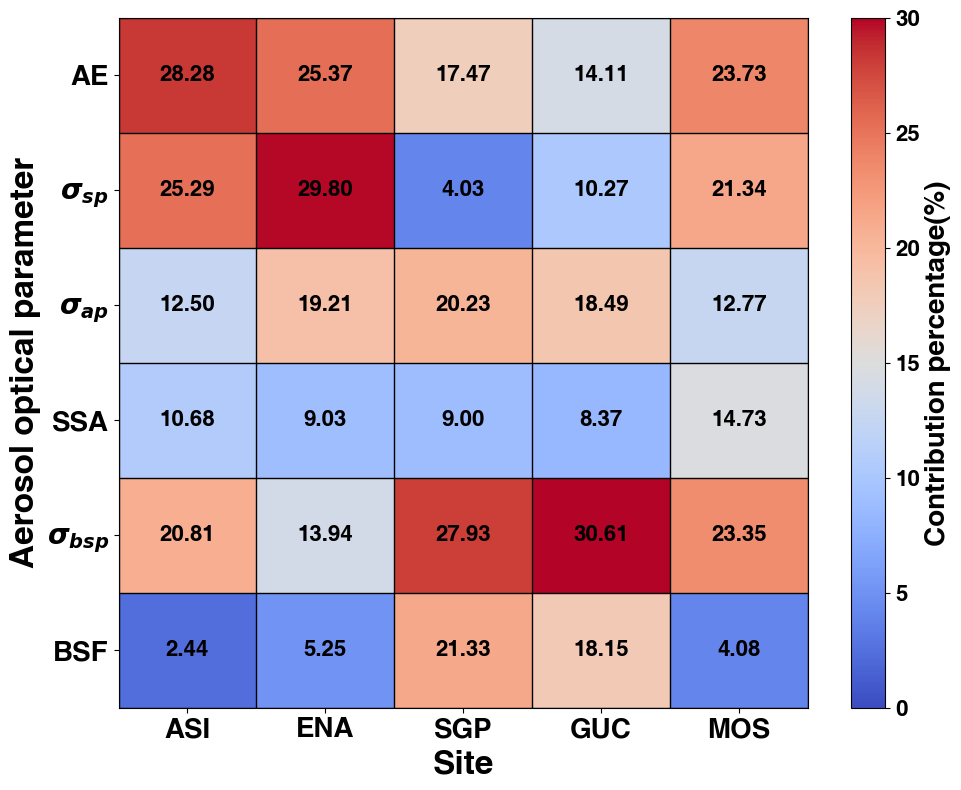

In [170]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams['font.weight'] = 'bold'

data = np.array([
    [AE_ASI, AE_ENA, AE_SGP, AE_GUC, AE_mos],
    [BS_ASI, BS_ENA, BS_SGP, BS_GUC, BS_mos],
    [BA_ASI, BA_ENA, BA_SGP, BA_GUC, BA_mos],
    [SSA_ASI, SSA_ENA, SSA_SGP, SSA_GUC, SSA_mos],
    # [G_ASI, G_ENA, G_SGP, G_GUC],
    [BBS_ASI, BBS_ENA, BBS_SGP, BBS_GUC, BBS_mos],
    # [TRAN_ASI, TRAN_ENA, TRAN_SGP, TRAN_GUC],
    [BSF_ASI, BSF_ENA, BSF_SGP, BSF_GUC, BSF_mos]
])
labels_grouped = ['ASI', 'ENA', 'SGP', 'GUC','MOS']
values_grouped = [
    (AE_ASI, BS_ASI, BA_ASI, SSA_ASI,  BBS_ASI,  BSF_ASI),
    (AE_ENA, BS_ENA, BA_ENA, SSA_ENA,  BBS_ENA,  BSF_ENA),
    (AE_SGP, BS_SGP, BA_SGP, SSA_SGP,  BBS_SGP,  BSF_SGP),
    (AE_GUC, BS_GUC, BA_GUC, SSA_GUC,  BBS_GUC,  BSF_GUC),
    (AE_mos, BS_mos, BA_mos, SSA_mos,  BBS_mos,  BSF_mos)
]

fig, ax = plt.subplots(figsize=(10, 8))

# Set vmin and vmax for color range control
cax = ax.imshow(data, cmap='coolwarm', aspect='auto', vmin=0, vmax=30)

cbar = fig.colorbar(cax, ax=ax, orientation='vertical')
cbar.ax.set_ylabel('Contribution percentage(%)', fontsize=20, fontname='Helvetica', fontweight='bold')
cbar.ax.tick_params(labelsize=16) 

ax.set_xticks(np.arange(len(labels_grouped)))
ax.set_xticklabels(labels_grouped, fontsize=20)
ax.set_yticks(np.arange(len(values_grouped[0])))
ax.set_yticklabels(['AE', '$\sigma_{sp}$', '$\sigma_{ap}$', 'SSA', '$\sigma_{bsp}$', 'BSF'], fontsize=20)

ax.set_xlabel('Site', fontsize=24, fontname='Helvetica', fontweight='bold')
ax.set_ylabel('Aerosol optical parameter', fontsize=24, fontname='Helvetica', fontweight='bold')

ax.set_xticks(np.arange(data.shape[1]+1)-0.5, minor=True)
ax.set_yticks(np.arange(data.shape[0]+1)-0.5, minor=True)
ax.grid(which="minor", color="k", linestyle='-', linewidth=1)
ax.tick_params(which="minor", size=0)

# Add text labels to each cell
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f'{data[i, j]:.2f}', ha='center', va='center', fontsize=16, fontname='Helvetica', color='black', fontweight='bold')

plt.tight_layout()
# plt.savefig('E:/aabc/summary/fig-250416/ccn_contribution_heatmap.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()
